In [1]:
# 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("설치가 완료되었습니다. 상단 메뉴의 [런타임] -> [세션 다시 시작]을 클릭한 후 아래 코드를 실행해주세요.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

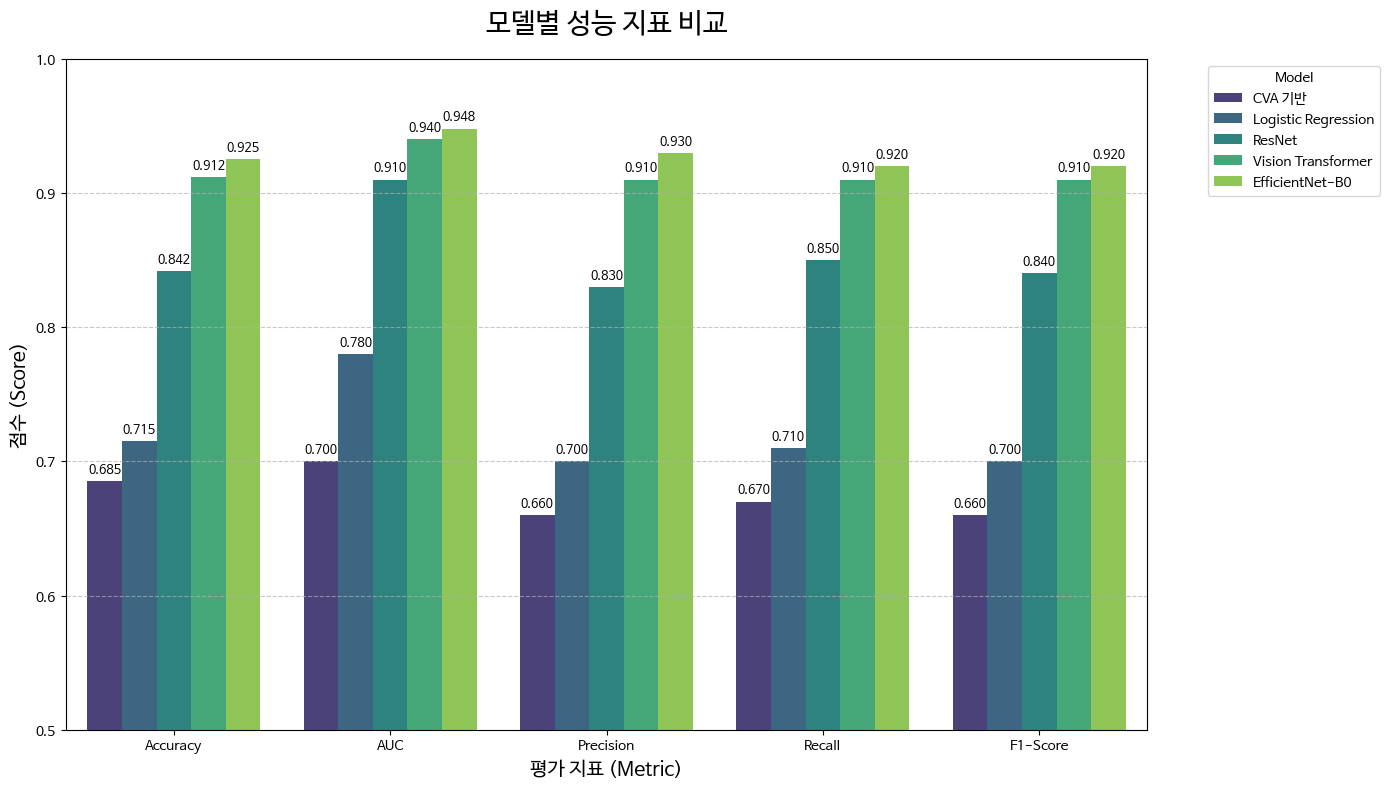

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.font_manager as fm

# 1. 한글 폰트 설정 (세션 다시 시작 후 실행)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 데이터 정의 (이미지의 수치 입력)
data = {
    'Model': [
        'CVA 기반',
        'Logistic Regression',
        'ResNet',
        'Vision Transformer',
        'EfficientNet-B0'
    ],
    'Accuracy': [0.685, 0.715, 0.842, 0.912, 0.925],
    'AUC': [0.7, 0.78, 0.91, 0.94, 0.948],
    'Precision': [0.66, 0.7, 0.83, 0.91, 0.93],
    'Recall': [0.67, 0.71, 0.85, 0.91, 0.92],
    'F1-Score': [0.66, 0.7, 0.84, 0.91, 0.92]
}

# DataFrame 변환
df = pd.DataFrame(data)

# 3. 데이터 재구조화 (시각화를 위해 Long format으로 변환)
df_melted = df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 4. 시각화 그리기
plt.figure(figsize=(14, 8))

# 막대 그래프 생성
ax = sns.barplot(
    data=df_melted,
    x='Metric',
    y='Score',
    hue='Model',
    palette='viridis' # 색상 테마 설정
)

# 그래프 꾸미기
plt.title('모델별 성능 지표 비교', fontsize=20, pad=20)
plt.xlabel('평가 지표 (Metric)', fontsize=14)
plt.ylabel('점수 (Score)', fontsize=14)
plt.ylim(0.5, 1.0) # y축 범위 설정 (차이가 잘 보이도록 조정)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model') # 범례 위치 조정
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 수치 표시 (선택 사항)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

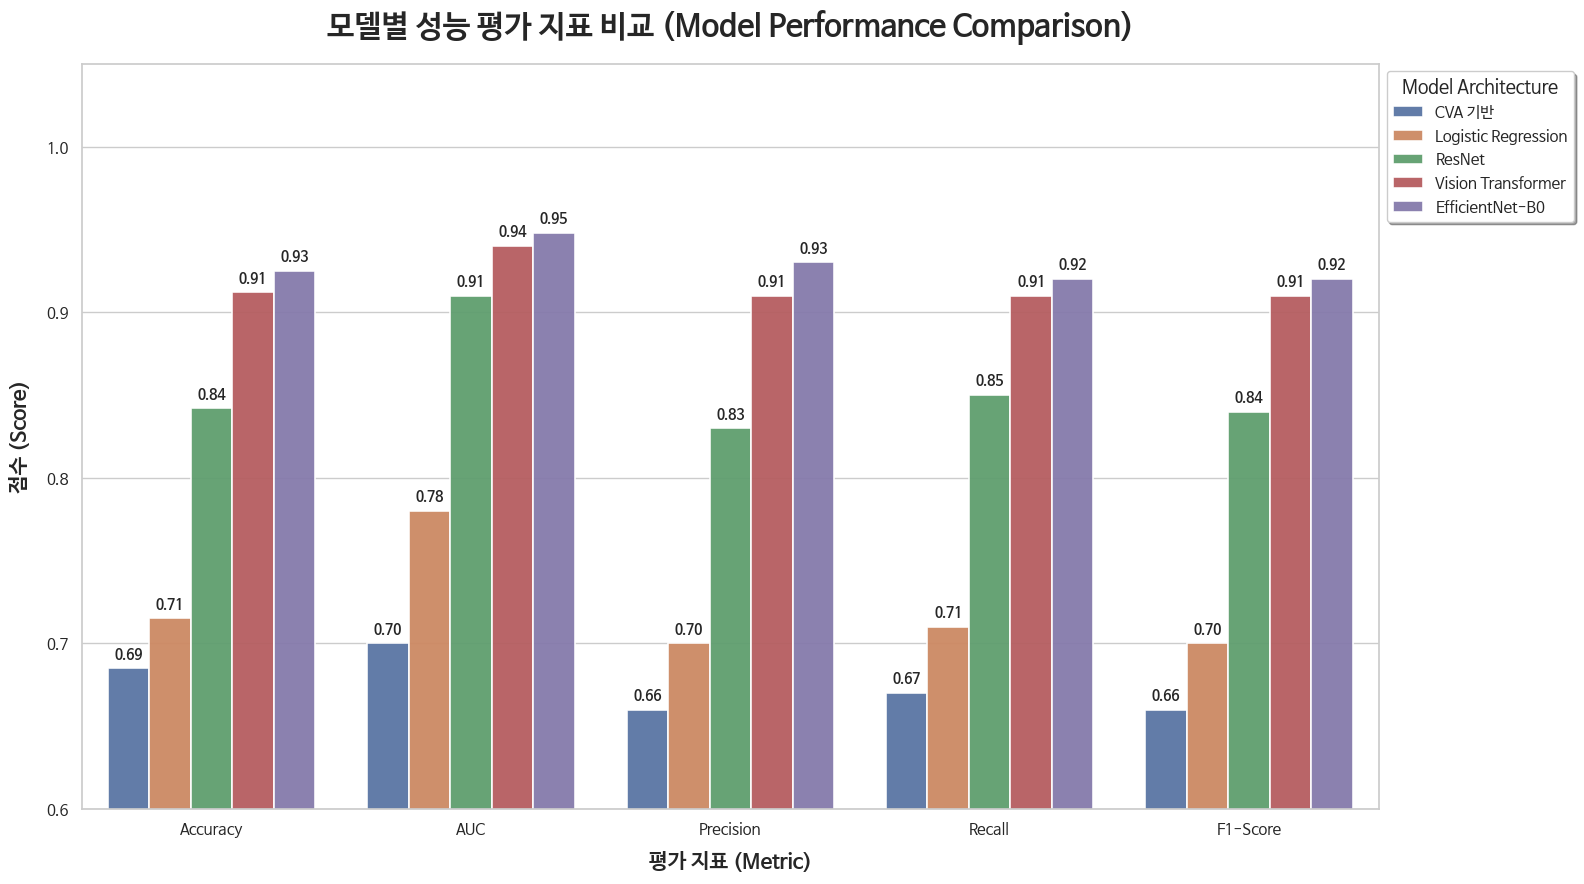

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 한글 폰트 및 Seaborn 테마 설정
plt.rc('font', family='NanumBarunGothic')  # Colab 한글 폰트
sns.set_theme(style="whitegrid", font='NanumBarunGothic') # 배경에 격자 무늬 추가로 수치 확인 용이하게 설정

# 2. 데이터 정의
data = {
    'Model': ['CVA 기반', 'Logistic Regression', 'ResNet', 'Vision Transformer', 'EfficientNet-B0'],
    'Accuracy': [0.685, 0.715, 0.842, 0.912, 0.925],
    'AUC': [0.7, 0.78, 0.91, 0.94, 0.948],
    'Precision': [0.66, 0.7, 0.83, 0.91, 0.93],
    'Recall': [0.67, 0.71, 0.85, 0.91, 0.92],
    'F1-Score': [0.66, 0.7, 0.84, 0.91, 0.92]
}

# DataFrame 변환 및 구조 변경 (Wide -> Long format)
df = pd.DataFrame(data)
df_melted = df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 3. 시각화 디자인 개선
plt.figure(figsize=(16, 9)) # 16:9 비율로 넓게 설정

# 막대 그래프 그리기
ax = sns.barplot(
    data=df_melted,
    x='Metric',
    y='Score',
    hue='Model',
    palette='deep',      # 'deep': 차분하고 전문적인 색상 팔레트
    edgecolor='white',   # 막대 테두리에 흰색 선 추가로 깔끔함 강조
    linewidth=1.2,       # 테두리 두께
    alpha=0.95           # 색상 투명도 (진하게)
)

# 4. 세부 요소 튜닝
# 제목과 축 레이블
plt.title('모델별 성능 평가 지표 비교 (Model Performance Comparison)', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('평가 지표 (Metric)', fontsize=15, labelpad=10, fontweight='bold')
plt.ylabel('점수 (Score)', fontsize=15, labelpad=10, fontweight='bold')

# Y축 범위 조정 (차이가 더 잘 보이도록 0.6부터 시작)
plt.ylim(0.6, 1.05)

# 막대 위 수치 표시 (가독성 개선)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=4, fontsize=10, fontweight='bold')

# 범례 디자인 (그래프 밖으로 깔끔하게 배치)
plt.legend(
    title='Model Architecture',
    title_fontsize='13',
    fontsize='11',
    loc='upper left',
    bbox_to_anchor=(1, 1), # 그래프 우측 상단 외부에 배치
    frameon=True,
    shadow=True,          # 범례에 그림자 효과
    facecolor='white'
)

plt.tight_layout()
plt.show()